In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# We merge the original datasets with the ones with the variables extracted by the LLM from video and caption

In [4]:
# DATASETS

reels = pd.read_csv("/kaggle/input/datasets/filippotenani/merging-data/reels_engineered.csv")
stories = pd.read_csv("/kaggle/input/datasets/filippotenani/merging-data/stories_engineered.csv")
hook = pd.read_excel("/kaggle/input/datasets/filippotenani/merging-data/hook.xlsx")
video = pd.read_excel("/kaggle/input/datasets/filippotenani/merging-data/video.xlsx")
caption = pd.read_excel("/kaggle/input/datasets/filippotenani/merging-data/caption.xlsx")
micro = pd.read_excel("/kaggle/input/datasets/filippotenani/merging-data/microcinetica.xlsx")

In [5]:
video.columns

Index(['file_name', 'f_index', 'times_analyzed', 'last_updated',
       'tone_video_api', 'tone_video_api_history', 'tone_video_human',
       'tone_video_match_human', 'tone_video_match_api',
       'voice_speed_video_api', 'voice_speed_video_api_history',
       'voice_speed_video_human', 'voice_speed_video_match_human',
       'voice_speed_video_match_api', 'microkinetics_video_api',
       'microkinetics_video_api_history', 'microkinetics_video_human',
       'microkinetics_video_match_human', 'microkinetics_video_match_api',
       'activity_video_api', 'activity_video_api_history',
       'activity_video_human', 'activity_video_match_human',
       'activity_video_match_api', 'format_video_api',
       'format_video_api_history', 'format_video_human',
       'format_video_match_human', 'format_video_match_api',
       'product_integration_api', 'product_integration_api_history',
       'product_integration_human', 'product_integration_match_human',
       'product_integration_mat

In [6]:
# the rows we want to keep with the extracted video variables plus the filename
# we do not keep microkinetics because a better one was extracted separately
video = video[["file_name", "tone_video_api", "voice_speed_video_api", "activity_video_api", "format_video_api",
              "product_integration_api", "funnel_api", "posizionamento_api"]]

In [7]:
hook.columns

Index(['file_name', 'f_index', 'times_analyzed', 'last_updated',
       'hook_score_api', 'hook_score_api_history', 'hook_score_human',
       'hook_score_match_human', 'hook_score_match_api'],
      dtype='object')

In [8]:
# the rows we want to keep with the extracted hook variable plus the filename
hook = hook[["file_name", "hook_score_api"]]

In [9]:
micro.columns

Index(['file_name', 'f_index', 'times_analyzed', 'last_updated',
       'microkinetics_video_api', 'microkinetics_video_api_history',
       'microkinetics_video_human', 'microkinetics_video_match_human',
       'microkinetics_video_match_api'],
      dtype='object')

In [10]:
# the rows we want to keep with the extracted microkinetics variable plus the filename
micro = micro[["file_name", "microkinetics_video_api"]]

In [11]:
caption.columns

Index(['file_name', 'f_index', 'times_analyzed', 'last_updated',
       'tone_caption_api', 'tone_caption_api_history', 'tone_caption_human',
       'tone_caption_match_human', 'tone_caption_match_api',
       'funnel_caption_api', 'funnel_caption_api_history',
       'funnel_caption_human', 'funnel_caption_match_human',
       'funnel_caption_match_api'],
      dtype='object')

In [12]:
# the rows we want to keep with the extracted caption variables plus the filename
caption = caption[["file_name", "tone_caption_api", "funnel_caption_api"]]

In [13]:
# put together reels and stories data one on top of the other
data = pd.concat([reels, stories])

In [14]:
data.shape

(3243, 37)

In [15]:
# rename file_name into Filename to match the one in data
video = video.rename(columns={"file_name": "Filename"})
hook = hook.rename(columns={"file_name": "Filename"})
micro = micro.rename(columns={"file_name": "Filename"})
caption = caption.rename(columns={"file_name": "Filename"})

In [16]:
# merge data and video
# left join to keep all unmatched rows from data
data = pd.merge(data, video, on="Filename", how="left")

In [17]:
# merge data and hook
# left join to keep all unmatched rows from data
data = pd.merge(data, hook, on="Filename", how="left")

In [18]:
# merge data and micro
# left join to keep all unmatched rows from data
data = pd.merge(data, micro, on="Filename", how="left")

In [19]:
# merge data and caption
# left join to keep all unmatched rows from data
data = pd.merge(data, caption, on="Filename", how="left")

In [20]:
# compute caption length
data["caption_length"] = data["Post caption"].str.split().str.len()

In [21]:
# check correctness
data.shape
data.isna().sum()

Creator name                    0
Creator_gender                  0
Filename                        0
Social permalink             2230
Channel                         0
Followers                       0
Type of content                 0
Post creation date              0
mese                            0
Weekend/Settimanale             0
Post creation time              0
fascia_oraria                   0
Post caption                 2230
Reach                           0
Likes                        2230
Comments                     2230
Total clicks                 1013
Brand name                      0
Industry                        0
Local                           0
Brand_SM                        0
media_duration_sec              0
face_frame_ratio                0
faccia                          0
first_face_position_ratio       0
motion_level                    0
saturation                      0
luminance                       0
contrast                        0
sharpness     

In [22]:
# some rows returned error during extraction because their corresponding video does not exist
data[data["Filename"] == "416_468_6449"]
# we remove those rows, there is no way to fix them because the video has not been provided
data = data[~data["tone_video_api"].astype(str).str.startswith("ERROR")]
data.shape # 80 rows removed

(3163, 49)

In [23]:
data["Type of content"].value_counts()

Type of content
INSTAGRAM_STORY    2182
INSTAGRAM_REEL      661
TIKTOK_POST         320
Name: count, dtype: int64

In [24]:
# separate reels and stories again
stories = data[data["Type of content"] == "INSTAGRAM_STORY"]
reels = data[(data["Type of content"] == "INSTAGRAM_REEL") | (data["Type of content"] == "TIKTOK_POST")]

In [25]:
stories.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'ENGAGE_RATE', 'COMM_PER_LIKE', 'CTR', 'tone_video_api',
       'voice_speed_video_api', 'activity_video_api', 'format_video_api',
       'product_integration_api', 'funnel_api', 'posizionamento_api',
       'hook_score_api', 'microkinetics_video_api', 'tone_caption_api',
       'funnel_caption_api', 'caption_length'],
      dtype='object')

In [26]:
# remove the variables not relevant for stories
stories = stories.drop(["ENGAGE_RATE", "COMM_PER_LIKE", "Likes", "Comments", 
                        "tone_caption_api", "funnel_caption_api", "caption_length"], axis=1)

# put the target variables as last columns
kpi = ["PERC_REACHED", "CTR"]
other_cols = [c for c in stories.columns if c not in kpi]
stories = stories[other_cols + kpi]

stories.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Total clicks', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'PERC_REACHED', 'CTR'],
      dtype='object')

In [27]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'ENGAGE_RATE', 'COMM_PER_LIKE', 'CTR', 'tone_video_api',
       'voice_speed_video_api', 'activity_video_api', 'format_video_api',
       'product_integration_api', 'funnel_api', 'posizionamento_api',
       'hook_score_api', 'microkinetics_video_api', 'tone_caption_api',
       'funnel_caption_api', 'caption_length'],
      dtype='object')

In [28]:
# remove the variables not relevant for the reels
reels = reels.drop(["CTR", "Total clicks"], axis=1)

# put the target variables as last columns
kpi = ["PERC_REACHED", "ENGAGE_RATE", "COMM_PER_LIKE"]
other_cols = [c for c in reels.columns if c not in kpi]
reels = reels[other_cols + kpi]

reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api',
       'caption_length', 'PERC_REACHED', 'ENGAGE_RATE', 'COMM_PER_LIKE'],
      dtype='object')

In [29]:
reels.to_csv("reels_extracted.csv", index=False)
stories.to_csv("stories_extracted.csv", index=False)

In [30]:
data.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'ENGAGE_RATE', 'COMM_PER_LIKE', 'CTR', 'tone_video_api',
       'voice_speed_video_api', 'activity_video_api', 'format_video_api',
       'product_integration_api', 'funnel_api', 'posizionamento_api',
       'hook_score_api', 'microkinetics_video_api', 'tone_caption_api',
       'funnel_caption_api', 'caption_length'],
      dtype='object')

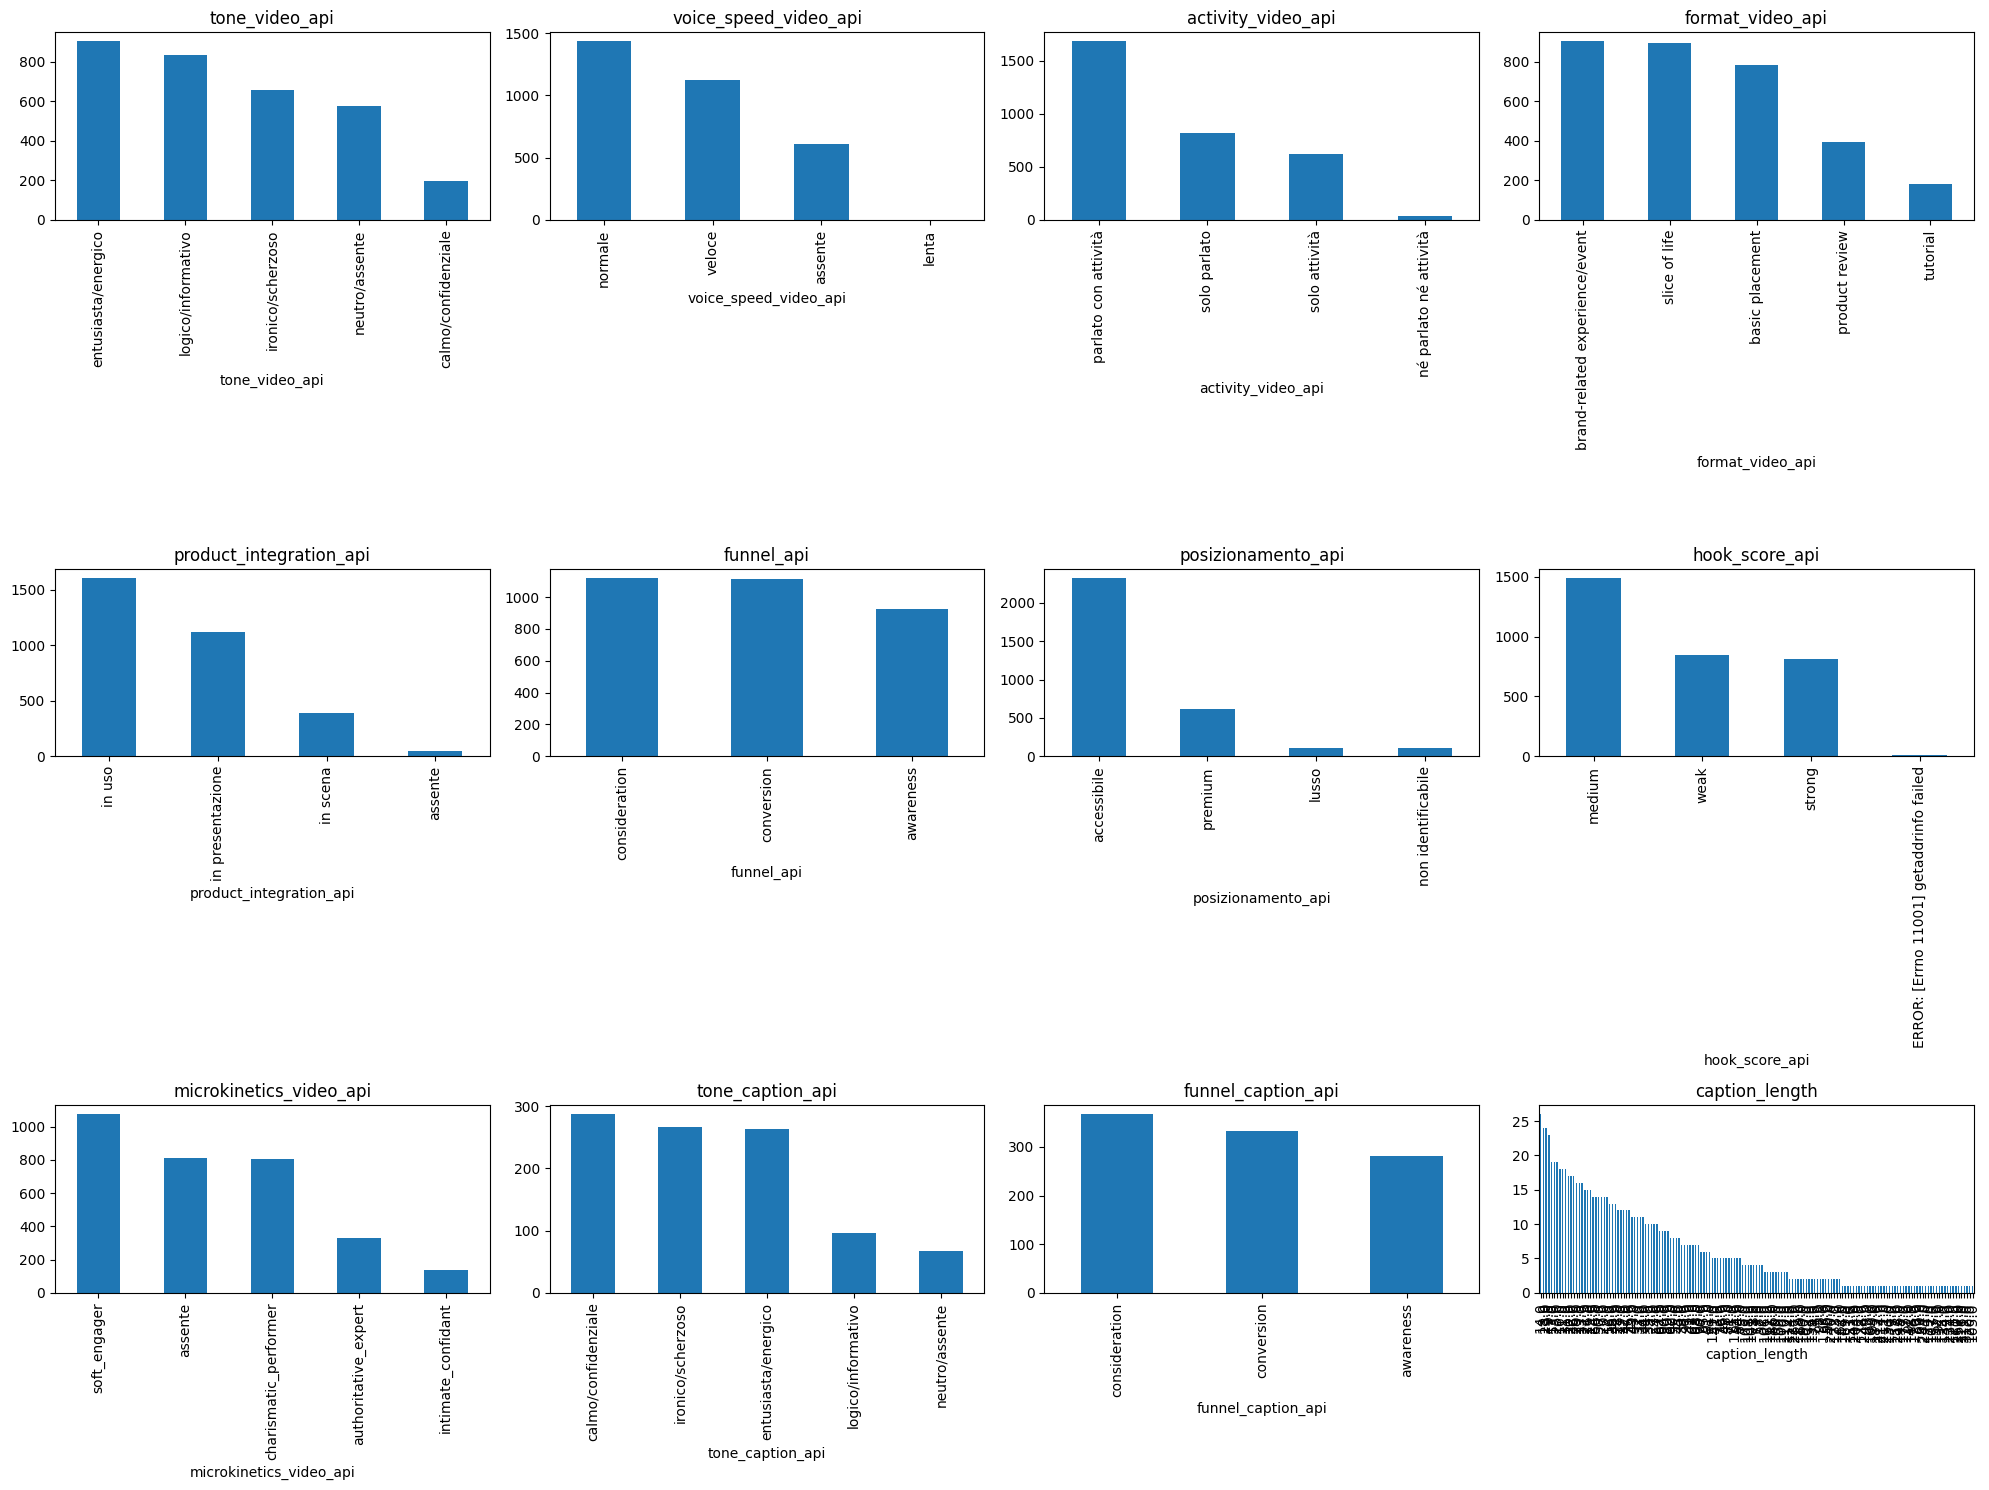

In [31]:
# check distribution of the variables extracted with the LLM to see if there are issues
cols = [
    "tone_video_api", "voice_speed_video_api", "activity_video_api",
    "format_video_api", "product_integration_api", "funnel_api",
    "posizionamento_api", "hook_score_api", "microkinetics_video_api",
    "tone_caption_api", "funnel_caption_api", "caption_length"
]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
for ax, col in zip(axes.flatten(), cols):
    data[col].value_counts().plot(kind='bar', ax=ax, title=col)
plt.tight_layout()
plt.show()